In [67]:
import importlib
import DblAttTransGAT

# Reload the module
importlib.reload(DblAttTransGAT)

# Now load autoreload properly
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from torch_geometric.nn import GATConv
import torch.nn.functional as F

from torch.utils.data import DataLoader

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

from DataEncoder import add_delta_time, deterministic_length_stratified_split, build_vocabs, compute_L_max
from DataEncoder import encode_numeric_features, encode_categorical_features, encode_time_targets, build_sequence_head, build_process_graph, time_cap
from DataEncoder import BPMOneShotDataset, audit_encoded_split, bpm_collate_fn
from DataEncoder import build_holdout_head, HoldoutGenerationDataset, bpm_collate_fn_hold

from DblAttTransGAT import ActivityGATEncoder, move_batch_to_device, GraphSequenceDoubleAttentionConfig, build_bigram_prior, generate_full_log
from DblAttTransGAT import build_model, compute_E_act_cache, build_optimizer, WarmupCosineScheduler, sanity_check_one_batch, EarlyStopping, train_one_epoch, evaluate, rmse_to_score
from DblAttTransGAT import build_optimizer_joint, build_schedulers, train_one_epoch_joint, EarlyStoppingJoint, load_for_inference, load_for_training, load_for_training_joint

from Visualization import make_regime_bundle, plot_graph_centric_ablation_panel, process_gat_attention, plot_gat_attention_panel

from Evaluation import evaluate_comprehensive, evaluate_light

import os 
import shutil

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
#dataname = "helpdesk"
dataname = "sepsis"
#dataname = "BPI13I"
#dataname = "BPI13C"
#dataname = "BPI20"
#dataname = "BPI12W"
#dataname = "BPI12"
#dataname = "BPI17"
#dataname = "BPI20R"

In [69]:
#event = pd.read_csv("../output/" + dataname + "_train.csv")
hold = pd.read_csv("../output/data_processed/" + dataname + "_hold.csv")
train_df = pd.read_csv("../output/data_processed/" + dataname + "_train_split.csv")
val_df = pd.read_csv("../output/data_processed/" + dataname + "_val_split.csv")

In [70]:
# event = add_delta_time(event, 'case:concept:name', 'time:timestamp', new_col="delta_time", norm=False)
hold = add_delta_time(hold, "case:concept:name", "time:timestamp", new_col="delta_time", norm=False)

In [71]:
case_index = 'case:concept:name'
time_col = 'time:timestamp'
core_event = "concept:name"
delta_col='delta_time'


In [72]:
if dataname == "helpdesk":
    cat_cols_event = ['org:resource']
    num_cols_event = []
    cat_cols_seq = ['case:variant']
    num_cols_seq = []
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq
elif dataname == "BPI12" or dataname == "BPI12W":
    event[case_index] = event[case_index].astype(str)
    hold[case_index] = hold[case_index].astype(str)
    #train_df[case_index] = train_df[case_index].astype(str)
    #val_df[case_index] = val_df[case_index].astype(str)
    cat_cols_event = ['org:resource']
    num_cols_event = []
    cat_cols_seq = []
    num_cols_seq = ['case:AMOUNT_REQ']
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq
elif dataname == "BPI13I" or dataname == "BPI13C":
    cat_cols_event = ['org:group', "resource country", "org:resource", "organization involved", "org:role"]
    num_cols_event = []
    cat_cols_seq = ["organization country", "impact", "product"]
    num_cols_seq = []
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq
elif dataname == "sepsis":
    cat_cols_event = ['org:group']
    num_cols_event = ['Leucocytes', 'CRP', 'LacticAcid']
    cat_cols_seq = ['InfectionSuspected', 'DiagnosticBlood',     'DisfuncOrg',  'SIRSCritTachypnea', 'Hypotensie',       'SIRSCritHeartRate', 
                    'Infusion',           'DiagnosticArtAstrup', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther',
                    'SIRSCriteria2OrMore', 'DiagnosticXthorax',  'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 
                    'DiagnosticLacticAcid', 'Diagnose',          'Hypoxie',             'DiagnosticUrinarySediment', 'DiagnosticECG']
    num_cols_seq = [ 'Age']
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq
elif dataname == "BPI17":
    cat_cols_event = ['Action', 'org:resource', 'EventOrigin', 'Accepted', 'Selected', "OfferID"]
    num_cols_event = ['FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost',  'CreditScore', 'OfferedAmount']
    cat_cols_seq = [ 'case:LoanGoal', 'case:ApplicationType']
    num_cols_seq = ['case:RequestedAmount']
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq
elif dataname == "BPI20":
    cat_cols_event = ['org:role']
    num_cols_event = []
    cat_cols_seq = ["case:OrganizationalEntity", "case:Project"]
    num_cols_seq = ["case:RequestedAmount", "case:Permit RequestedBudget"]  
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq
elif dataname == "BPI20R":
    cat_cols_event = ['org:resource','org:role']
    num_cols_event = []
    cat_cols_seq = ["case:OrganizationalEntity", "case:Project", "case:RfpNumber", "case:Task", "case:Activity"]
    num_cols_seq = ["case:RequestedAmount"]  
    positive_event_cols = num_cols_event
    positive_seq_cols = num_cols_seq

In [73]:
#compute the longest case
L_max = compute_L_max(train_df, case_index, True)

In [74]:
# vacabulary for categorical data
vocabs = build_vocabs(train_df, core_event, cat_cols_event, cat_cols_seq, True, True,True)

In [75]:
event_num_tr, seq_num_tr, num_stats = encode_numeric_features(train_df, case_index, time_col, num_cols_event, num_cols_seq, L_max, stats=None, fit=True, positive_event_cols = positive_event_cols, positive_seq_cols = positive_seq_cols)
event_num_val, seq_num_val, _ = encode_numeric_features(val_df, case_index, time_col, num_cols_event, num_cols_seq, L_max, stats=num_stats, fit=False, positive_event_cols = positive_event_cols, positive_seq_cols = positive_seq_cols)

In [76]:
activity_tr, event_cat_tr, seq_cat_tr, mask_tr, lengths_tr = encode_categorical_features(train_df, case_index, time_col, 
                                                                                        core_event, cat_cols_event, cat_cols_seq, vocabs, L_max)
activity_val, event_cat_val, seq_cat_val, mask_val, lengths_val = encode_categorical_features(val_df, case_index, time_col,
                                                                                              core_event, cat_cols_event, cat_cols_seq, vocabs, L_max)

In [77]:
time_log_tr, time_stats = encode_time_targets(train_df, case_index, time_col, delta_col, L_max, stats=None, fit=True)
time_log_val, _ = encode_time_targets(val_df, case_index, time_col, delta_col, L_max, stats=time_stats, fit=False)

time_min_scaled, time_max_scaled = time_cap(train_df, delta_col, time_stats)

In [78]:
seq_head_tr, case_ids_tr, start_times_tr = build_sequence_head(train_df, case_index, time_col, lengths_tr, L_max)
seq_head_val, case_ids_val, start_times_val = build_sequence_head(val_df, case_index, time_col, lengths_val, L_max)

In [79]:
train_dataset = BPMOneShotDataset(seq_head_tr, seq_cat_tr, seq_num_tr, activity_tr, time_log_tr, event_cat_tr, event_num_tr, mask_tr, lengths_tr, case_ids_tr, start_times_tr)
val_dataset = BPMOneShotDataset(seq_head_val, seq_cat_val, seq_num_val, activity_val, time_log_val, event_cat_val, event_num_val, mask_val, lengths_val, case_ids_val, start_times_val)

In [80]:
train_encoded = {
    "seq_head": seq_head_tr,
    "mask": mask_tr,
    "lengths": lengths_tr,
    "y_activity": activity_tr,
    "y_time_log": time_log_tr,
    "seq_cat": seq_cat_tr,
    "event_cat": event_cat_tr,
    "seq_numeric": seq_num_tr,
    "event_numeric": event_num_tr,
}

audit_encoded_split("TRAIN", train_encoded, vocabs)


========== AUDIT: TRAIN ==========
N cases: 756 | L_max: 186
seq_head: ((756, 5), torch.float32)
mask: ((756, 186), torch.float32)
lengths: ((756,), torch.int64)
y_activity: ((756, 186), torch.int64)
y_time_log: ((756, 186), torch.float32)
Max raw length: 186
Cases truncated: 0

Seq categorical cols: ['InfectionSuspected', 'DiagnosticBlood', 'DisfuncOrg', 'SIRSCritTachypnea', 'Hypotensie', 'SIRSCritHeartRate', 'Infusion', 'DiagnosticArtAstrup', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther', 'SIRSCriteria2OrMore', 'DiagnosticXthorax', 'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 'DiagnosticLacticAcid', 'Diagnose', 'Hypoxie', 'DiagnosticUrinarySediment', 'DiagnosticECG']
  seq_cat[InfectionSuspected]: ((756,), torch.int64)
  seq_cat[DiagnosticBlood]: ((756,), torch.int64)
  seq_cat[DisfuncOrg]: ((756,), torch.int64)
  seq_cat[SIRSCritTachypnea]: ((756,), torch.int64)
  seq_cat[Hypotensie]: ((756,), torch.int64)
  seq_cat[SI

In [81]:
val_encoded = {
    "seq_head": seq_head_val,
    "mask": mask_val,
    "lengths": lengths_val,
    "y_activity": activity_val,
    "y_time_log": time_log_val,
    "seq_cat": seq_cat_val,
    "event_cat": event_cat_val,
    "seq_numeric": seq_num_val,
    "event_numeric": event_num_val,
}

audit_encoded_split("VAL", val_encoded, vocabs)


========== AUDIT: VAL ==========
N cases: 189 | L_max: 186
seq_head: ((189, 5), torch.float32)
mask: ((189, 186), torch.float32)
lengths: ((189,), torch.int64)
y_activity: ((189, 186), torch.int64)
y_time_log: ((189, 186), torch.float32)
Max raw length: 60
Cases truncated: 0

Seq categorical cols: ['InfectionSuspected', 'DiagnosticBlood', 'DisfuncOrg', 'SIRSCritTachypnea', 'Hypotensie', 'SIRSCritHeartRate', 'Infusion', 'DiagnosticArtAstrup', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther', 'SIRSCriteria2OrMore', 'DiagnosticXthorax', 'SIRSCritTemperature', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 'DiagnosticLacticAcid', 'Diagnose', 'Hypoxie', 'DiagnosticUrinarySediment', 'DiagnosticECG']
  seq_cat[InfectionSuspected]: ((189,), torch.int64)
  seq_cat[DiagnosticBlood]: ((189,), torch.int64)
  seq_cat[DisfuncOrg]: ((189,), torch.int64)
  seq_cat[SIRSCritTachypnea]: ((189,), torch.int64)
  seq_cat[Hypotensie]: ((189,), torch.int64)
  seq_cat[SIRSC

In [85]:
head_graph_tr = build_process_graph(train_df, core_event, case_index, time_col, delta_col, vocabs)

In [86]:
model_cfg = {
    # sequence length
    "L_max": int(L_max),
    # activity (graph + classifier)
    "num_activities": len(vocabs["activity"]),
    "pad_id": vocabs["activity"]["<PAD>"],
    "unk_id": vocabs["activity"]["<UNK>"],
    "eos_id": vocabs["activity"]["<EOS>"],
    "sos_id": vocabs["activity"]["<SOS>"],
    # case numeric conditioning
    "d_case_num": seq_head_tr.shape[1],  # length_norm + 4 time dims (+ any seq numeric if you later add)
    # sequence categorical (case-level) vocab sizes
    "seq_cat_vocab_sizes": { c: len(vocabs["seq_cat"][c]) for c in vocabs["seq_cat"]},
    # event categorical (per-timestep) vocab sizes
    "event_cat_vocab_sizes": { c: len(vocabs["event_cat"][c]) for c in vocabs["event_cat"]},
    # event numeric dims (per-timestep)
    "event_num_cols": list(event_num_tr.keys()),  
    # sequence numeric dims (case-level)
    "seq_num_cols": list(seq_num_tr.keys()),  
    # graph edge features
    "edge_attr_dim": int(head_graph_tr["edge_attr"].shape[1]),
}

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d_model = 256

gat_encoder = ActivityGATEncoder(
        num_activities = model_cfg["num_activities"],
        d_model = d_model,    
        edge_dim = model_cfg["edge_attr_dim"],
        num_layers = 2,
        heads = 4,
        dropout = 0.05,
        use_norm = True,
        init_scale = 0.01
).to(device)

edge_index = head_graph_tr["edge_index"].to(device)
edge_attr = head_graph_tr["edge_attr"].to(device)

E_act, ei_head, alpha_head = gat_encoder(edge_index, edge_attr, return_attention=True)


In [88]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,          # set >0 later if stable
    pin_memory=True,
    collate_fn=bpm_collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=bpm_collate_fn,
    drop_last=False,
)

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [90]:
if dataname == "sepsis":
    w_event_cat = 0.15
    w_event_num = 0.1
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0.05
    unary_weight = 0.55
elif dataname == "BPI17":
    w_event_cat = 0.15
    w_event_num = 0.1
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0.05
    unary_weight = 3
elif dataname == "helpdesk":
    w_event_cat = 0.8
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0.5
    w_seq_num = 0
    unary_weight = 0.55
elif dataname == "BPI12" or dataname == "BPI12W" :
    w_event_cat = 0.1
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0
    w_seq_num = 0.05
    unary_weight = 0.55
elif dataname == "BPI13I" or dataname == "BPI13C":
    w_event_cat = 0.15
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0
    if dataname == "BPI13I":
       unary_weight = 3
    elif dataname == "BPI13C":
       unary_weight = 0.55        
elif dataname == "BPI20" or dataname == "BPI20R":
    w_event_cat = 0.15
    w_event_num = 0
    # case (sequence-level) prediction weights
    w_seq_cat = 0.05
    w_seq_num = 0.05
    unary_weight = 0.55

In [91]:
model_joint_stage10 = build_model(
    L_max = model_cfg["L_max"],                         # your padded max trace length
    num_activities = model_cfg["num_activities"],   # activity vocabulary size
    d_case_num = model_cfg['d_case_num'],          # case feature dimension
    d_model = d_model,
    n_layers = 4,
    n_heads = 4,
    dropout = 0.2,
    ff_mult = 4,
    ff_mult_x = 4,
    gate_init = 0.05,
    length_bins = model_cfg["L_max"], 
    
    # keep them as default 
    latent_dim = 0,                             # keep OFF 
    latent_std = 1.0,
    # loss weights
    w_activity = 1.0,
    w_time = 0.1,
    w_length = 0.25,
    w_event_cat = w_event_cat,
    w_event_num = w_event_num,
    # case (sequence-level) prediction weights
    w_seq_cat = w_seq_cat,
    w_seq_num = w_seq_num,
    w_transition_penalty = 0,
    # decoding stabilizer
    use_activity_bias = True,
    # activity ids reserved
    pad_id = 0,
    unk_id = 1,
    eos_id = 2,
    sos_id = 3,
    
    # head
    activity_decoder = "cosine_linear",  # allow values "cosine_linear", "cosine", "linear"
    
    # final activity setup
    w_final_activity = 5.0,
    w_preterminal_activity = 3.0,
    use_activity_feedback=True,
    n_refine_layers=1,
    activity_feedback_gate_init=0.3,
    activity_feedback_temp=1,
    use_transition_bias = True,
    transition_bias_weight = 0.5,
    unary_weight = unary_weight,

    # optional
    event_cat_dims = model_cfg["event_cat_vocab_sizes"] ,
    event_num_names = model_cfg['event_num_cols'],
    seq_cat_dims=model_cfg["seq_cat_vocab_sizes"],
    seq_num_names=model_cfg["seq_num_cols"]
    
).to(device)


opt_seq, opt_gat = build_optimizer_joint(
    seq_model=model_joint_stage10,
    gat_encoder=gat_encoder,
    lr_seq=2e-4,
    lr_gat=2e-5,
    weight_decay= 3e-4
)
num_epochs = 300
scheduler_epochs = 300
steps_per_epoch = len(train_loader)
#total_steps = steps_per_epoch * num_epochs
total_steps = steps_per_epoch * scheduler_epochs
warmup_steps = int(0.05 * total_steps)
sched_seq, sched_gat = build_schedulers(opt_seq, 
                                        opt_gat,
                                        warmup_steps=warmup_steps,
                                        total_steps=total_steps,
                                        min_lr_mult=0.1)

attn_save_path_joint_stage10 = "../output/checkpoints/" + dataname + "_best_attention_joint_stage10.pt"
history_path_joint_stage10 = "../output/checkpoints/" + dataname + "_history_joint_stage10.pt"
model_path_joint_stage10 = "../output/checkpoints/" + dataname + "_double_attention_best_model_joint_stage10.pt"


In [92]:
early_stopper_joint_stage10 = EarlyStoppingJoint(patience=40, checkpoint_path=model_path_joint_stage10)

history_joint_stage10 = {
    "train_loss": [],
    "val_loss": [],
    
    "train_act_acc": [],
    "val_act_acc": [],

    "train_act_no_eos_acc": [],
    "val_act_no_eos_acc": [],

    "train_act_final_acc": [],
    "val_act_final_acc": [],

    "train_act_preterm_acc": [],
    "val_act_preterm_acc": [],
    
    "train_len_acc": [],
    "val_len_acc": [],
    
    "train_time_rmse": [],
    "val_time_rmse": [],
    
    "train_event_cat_acc": [],
    "val_event_cat_acc": [],
    
    "train_event_num_rmse": [],
    "val_event_num_rmse": [],
    
    "train_seq_cat_acc": [],
    "val_seq_cat_acc": [],
    
    "train_seq_num_rmse": [],
    "val_seq_num_rmse": [],
    
    "lr_seq": [],
    "lr_gat": [],

    "train_E_act": [],
    "val_E_act": []
}
unfreeze_epoch = 10

for epoch in range(num_epochs):

    train_gat = (epoch >= unfreeze_epoch)

    train_loss, train_acc, train_no_eos_acc, train_final_acc, train_preterm_acc, train_len_acc, train_time_rmse, train_event_acc, train_event_rmse, train_seq_acc, train_seq_rmse, train_E_act, train_attn = train_one_epoch_joint(
        model_joint_stage10, gat_encoder, train_loader, head_graph_tr,
        opt_seq, opt_gat, sched_seq, sched_gat, device, epoch, train_gat,
        capture_attn=True,
        attn_batch_idx=epoch % len(train_loader)
    )

    val_loss, val_acc, val_no_eos_acc, val_final_acc, val_preterm_acc,val_len_acc, val_time_rmse, val_event_acc, val_event_rmse, val_seq_acc, val_seq_rmse, val_E_act, val_attn = evaluate(
        model_joint_stage10, gat_encoder, val_loader, head_graph_tr,
        device,
        capture_attn=True,
        attn_batch_idx=epoch % len(val_loader)
    )

    current_lr_seq = opt_seq.param_groups[0]["lr"]
    current_lr_gat = opt_gat.param_groups[0]["lr"]

    history_joint_stage10["train_loss"].append(train_loss)
    history_joint_stage10["val_loss"].append(val_loss)
    
    history_joint_stage10["train_act_acc"].append(train_acc)
    history_joint_stage10["val_act_acc"].append(val_acc)

    history_joint_stage10["train_act_no_eos_acc"].append(train_no_eos_acc)
    history_joint_stage10["val_act_no_eos_acc"].append(val_no_eos_acc)
    
    history_joint_stage10["train_act_final_acc"].append(train_final_acc)
    history_joint_stage10["val_act_final_acc"].append(val_final_acc)

    history_joint_stage10["train_act_preterm_acc"].append(train_preterm_acc)
    history_joint_stage10["val_act_preterm_acc"].append(val_preterm_acc)
    
    history_joint_stage10["train_len_acc"].append(train_len_acc)
    history_joint_stage10["val_len_acc"].append(val_len_acc)
    
    history_joint_stage10["train_time_rmse"].append(train_time_rmse)
    history_joint_stage10["val_time_rmse"].append(val_time_rmse)
    
    history_joint_stage10["train_event_cat_acc"].append(train_event_acc)
    history_joint_stage10["val_event_cat_acc"].append(val_event_acc)
    
    history_joint_stage10["train_event_num_rmse"].append(train_event_rmse)
    history_joint_stage10["val_event_num_rmse"].append(val_event_rmse)
    
    history_joint_stage10["train_seq_cat_acc"].append(train_seq_acc)
    history_joint_stage10["val_seq_cat_acc"].append(val_seq_acc)
    
    history_joint_stage10["train_seq_num_rmse"].append(train_seq_rmse)
    history_joint_stage10["val_seq_num_rmse"].append(val_seq_rmse)
    
    history_joint_stage10["lr_seq"].append(current_lr_seq)
    history_joint_stage10["lr_gat"].append(current_lr_gat)

    history_joint_stage10["train_E_act"].append(train_E_act.numpy())
    history_joint_stage10["val_E_act"].append(val_E_act.numpy())

    evt_num_s = rmse_to_score(val_event_rmse, c=1.0)
    seq_num_s = rmse_to_score(val_seq_rmse, c=1.0)
    time_s = rmse_to_score(val_time_rmse, c=0.5)

    if dataname == "sepsis":
        val_score = (0.96 * val_no_eos_acc + 0.005 * val_seq_acc + 0.01 * val_event_acc + 0.005 * seq_num_s + 0.01 * evt_num_s + 0.01 * time_s)
    elif dataname == "BPI17":
        val_score = (0.93 * val_no_eos_acc + 0.01 * val_seq_acc + 0.02 * val_event_acc + 0.01 * seq_num_s + 0.02 * evt_num_s + 0.01 * time_s)
    elif dataname == "helpdesk":  
        val_score = 0.75 * val_no_eos_acc + 0.03 * val_seq_acc + 0.2 * val_event_acc + 0.02 * time_s
    elif dataname == "BPI12" or dataname == "BPI12W":  
        val_score = 0.93 * val_no_eos_acc + 0.02 * seq_num_s + 0.03 * val_event_acc + 0.02 * time_s
    elif dataname == "BPI13I" or dataname == "BPI13C":  
        val_score = 0.8 * val_no_eos_acc + 0.03 * val_seq_acc + 0.15 * val_event_acc + 0.02 * time_s
    elif dataname == "BPI20" or dataname == "BPI20R":
        val_score = 0.85 * val_no_eos_acc + 0.02 * val_seq_acc + 0.1 * val_event_acc + 0.02 * seq_num_s + 0.01 * time_s
   
    saved = early_stopper_joint_stage10.step(val_score, val_no_eos_acc, model_joint_stage10, gat_encoder, opt_seq, opt_gat, sched_seq, sched_gat, epoch)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"ActAcc {train_acc:.4f}/{val_acc:.4f} | "
        f"ActNoEosAcc {train_no_eos_acc:.4f}/{val_no_eos_acc:.4f} | "
        f"ActFinalAcc {train_final_acc:.4f}/{val_final_acc:.4f} | "
        f"ActPretermAcc {train_preterm_acc:.4f}/{val_preterm_acc:.4f} | "
        f"LenAcc {train_len_acc:.4f}/{val_len_acc:.4f} | "
        f"TimeRMSE {train_time_rmse:.4f}/{val_time_rmse:.4f} | "
        f"EvtCat {train_event_acc:.4f}/{val_event_acc:.4f} | "
        f"EvtNum {train_event_rmse:.4f}/{val_event_rmse:.4f} | "
        f"SeqCat {train_seq_acc:.4f}/{val_seq_acc:.4f} | "
        f"SeqNum {train_seq_rmse:.4f}/{val_seq_rmse:.4f}"
    )
    
    # Example: inspect attention shapes once
    if epoch == 0 and train_attn is not None:
        if train_attn["gat_alpha"] is not None:
            print("GAT alpha:", tuple(train_attn["gat_alpha"].shape))
        if train_attn["transformer_attn"] is not None:
            if isinstance(train_attn["transformer_attn"], list):
                print("Transformer attn (last):", tuple(train_attn["transformer_attn"][-1].shape))
        if train_attn["graph_attn"] is not None:
            print("Graph cross attn:", tuple(train_attn["graph_attn"].shape))

    if saved:
        print(">>> New best model saved.")
    
        attn_pack_joint_stage10 = {
            "epoch": epoch,
            "attn_batch_idx": epoch % len(val_loader),
            "val_acc": val_acc,
            "val_no_eos_acc": val_no_eos_acc,
            "val_time_rmse": val_time_rmse,
            "val_event_acc": val_event_acc,
            "val_event_rmse": val_event_rmse,           
            "val_seq_acc": val_seq_acc,
            "val_seq_rmse": val_seq_rmse,
            "best_score": val_score,
            "id2activity": head_graph_tr["id2activity"],
            "mask": val_attn["mask"].cpu() if val_attn and val_attn.get("mask") is not None else None,
            "y_activity": val_attn["y_activity"].cpu() if val_attn and val_attn.get("y_activity") is not None else None,
            "pred_activity": val_attn["pred_activity"].cpu() if val_attn and val_attn.get("pred_activity") is not None else None,
            "activity_logits_1": (val_attn["activity_logits_1"].cpu() if val_attn and val_attn.get("activity_logits_1") is not None else None),
            "activity_logits": (val_attn["activity_logits"].cpu() if val_attn and val_attn.get("activity_logits") is not None else None),
            "gat_edge_index": (val_attn["gat_edge_index"].detach().cpu()
                               if val_attn and val_attn.get("gat_edge_index") is not None
                               else None),
            "gat_alpha": (val_attn["gat_alpha"].detach().cpu() if val_attn and val_attn.get("gat_alpha") is not None else None),
            "transformer_attn": ([a.detach().cpu() for a in val_attn["transformer_attn"]]
                                 if val_attn and isinstance(val_attn.get("transformer_attn"), list) else None),
            "graph_attn": (val_attn["graph_attn"].detach().cpu() if val_attn and val_attn.get("graph_attn") is not None else None),
        }
        torch.save(attn_pack_joint_stage10, attn_save_path_joint_stage10)
        torch.save(history_joint_stage10, history_path_joint_stage10)

    if early_stopper_joint_stage10.should_stop:
        print(f"\nEARLY STOPPING at epoch {epoch+1}")
        break


===== LOSS BREAKDOWN =====
loss: 5.4108
activity_loss: 3.3020
final_activity_loss: 3.3897
preterminal_activity_loss: 3.2133
time_loss: 0.6576
length_loss: 5.2703
transition_penalty: 0.0000
event_cat_loss: 3.2460
event_num_loss: 0.9623
seq_cat_loss: 1.5491
seq_num_loss: 1.2980

Epoch 001 | Loss 5.3485/4.9097 | ActAcc 0.0602/0.0944 | ActNoEosAcc 0.0616/0.0842 | ActFinalAcc 0.0398/0.2569 | ActPretermAcc 0.0625/0.0637 | LenAcc 0.0057/0.0039 | TimeRMSE 0.9851/0.9913 | EvtCat 0.0881/0.1211 | EvtNum 0.9878/0.9478 | SeqCat 0.2025/0.2670 | SeqNum 1.1884/1.0242
GAT alpha: (140, 4)
Transformer attn (last): (64, 4, 186, 186)
Graph cross attn: (64, 4, 186, 20)
>>> New best model saved.
Epoch 002 | Loss 4.7713/4.4136 | ActAcc 0.1152/0.1264 | ActNoEosAcc 0.0904/0.0902 | ActFinalAcc 0.4673/0.6912 | ActPretermAcc 0.0526/0.0000 | LenAcc 0.0085/0.0160 | TimeRMSE 0.9738/0.9764 | EvtCat 0.1417/0.3170 | EvtNum 0.9642/0.9196 | SeqCat 0.3727/0.6270 | SeqNum 1.1875/1.0273
>>> New best model saved.
Epoch 003 |

In [24]:
history_frozen = torch.load("../output/checkpoints/" + dataname + "_history.pt", map_location="cpu", weights_only=False)
history_unfreeze_5 = torch.load("../output/checkpoints/" + dataname + "_history_joint_stage.pt", map_location="cpu", weights_only=False)
history_unfreeze_10 = torch.load("../output/checkpoints/" + dataname + "_history_joint_stage10.pt", map_location="cpu", weights_only=False)
history_full_unfrozen = torch.load("../output/checkpoints/" + dataname + "_history_joint.pt", map_location="cpu", weights_only=False)

In [25]:
regime_frozen = make_regime_bundle(
    name="Frozen GAT",
    history=history_frozen,
    acc_key="val_act_no_eos_acc",
    E_key="val_E_act",
)

regime_unfreeze_5 = make_regime_bundle(
    name="Unfreeze at epoch 5",
    history=history_unfreeze_5,
    acc_key="val_act_no_eos_acc",
    E_key="val_E_act",
)

regime_unfreeze_10 = make_regime_bundle(
    name="Unfreeze at epoch 10",
    history=history_unfreeze_10,
    acc_key="val_act_no_eos_acc",
    E_key="val_E_act",
)

regime_full_unfrozen = make_regime_bundle(
    name="Fully unfrozen",
    history=history_full_unfrozen,
    acc_key="val_act_no_eos_acc",
    E_key="val_E_act",
)

Saved: ../output/plots/BPI20R_ablation_curve.png and ../output/plots/BPI20R_ablation_curve.pdf


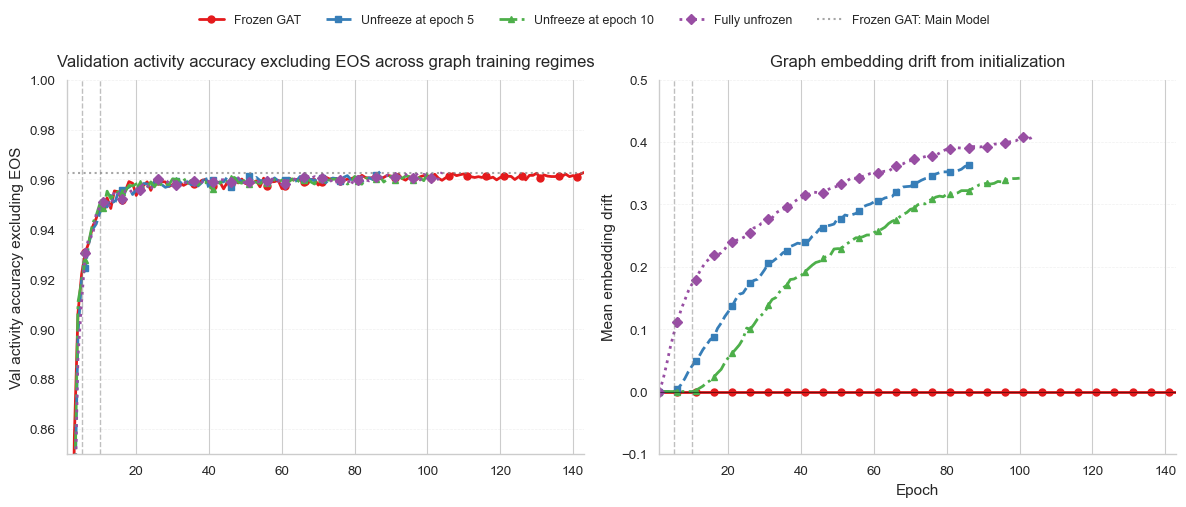

In [28]:
plot_graph_centric_ablation_panel(
    regime_bundles=[
        regime_frozen,
        regime_unfreeze_5,
        regime_unfreeze_10,
        regime_full_unfrozen,
    ],
    unfreeze_epochs=[5, 10],
    figsize=(12, 5),
    save_path="../output/plots/" + dataname + "_ablation_curve",
    acc_ylim=(0.85, 1),   # optional, useful if curves are too flat
    drift_ylim=(-0.1, 0.5),  # optional
)

In [29]:
attn_frozen = torch.load("../output/checkpoints/" + dataname + "_best_attention.pt", map_location="cpu")
attn_frozen5 = torch.load("../output/checkpoints/" + dataname + "_best_attention_joint_stage.pt", map_location="cpu")
attn_frozen10 = torch.load("../output/checkpoints/" + dataname + "_best_attention_joint_stage10.pt", map_location="cpu")
attn_unfrozen = torch.load("../output/checkpoints/" + dataname + "_best_attention_joint.pt", map_location="cpu")

Saved: ../output/plots/BPI20R_gat_attention_panel.png and ../output/plots/BPI20R_gat_attention_panel.pdf


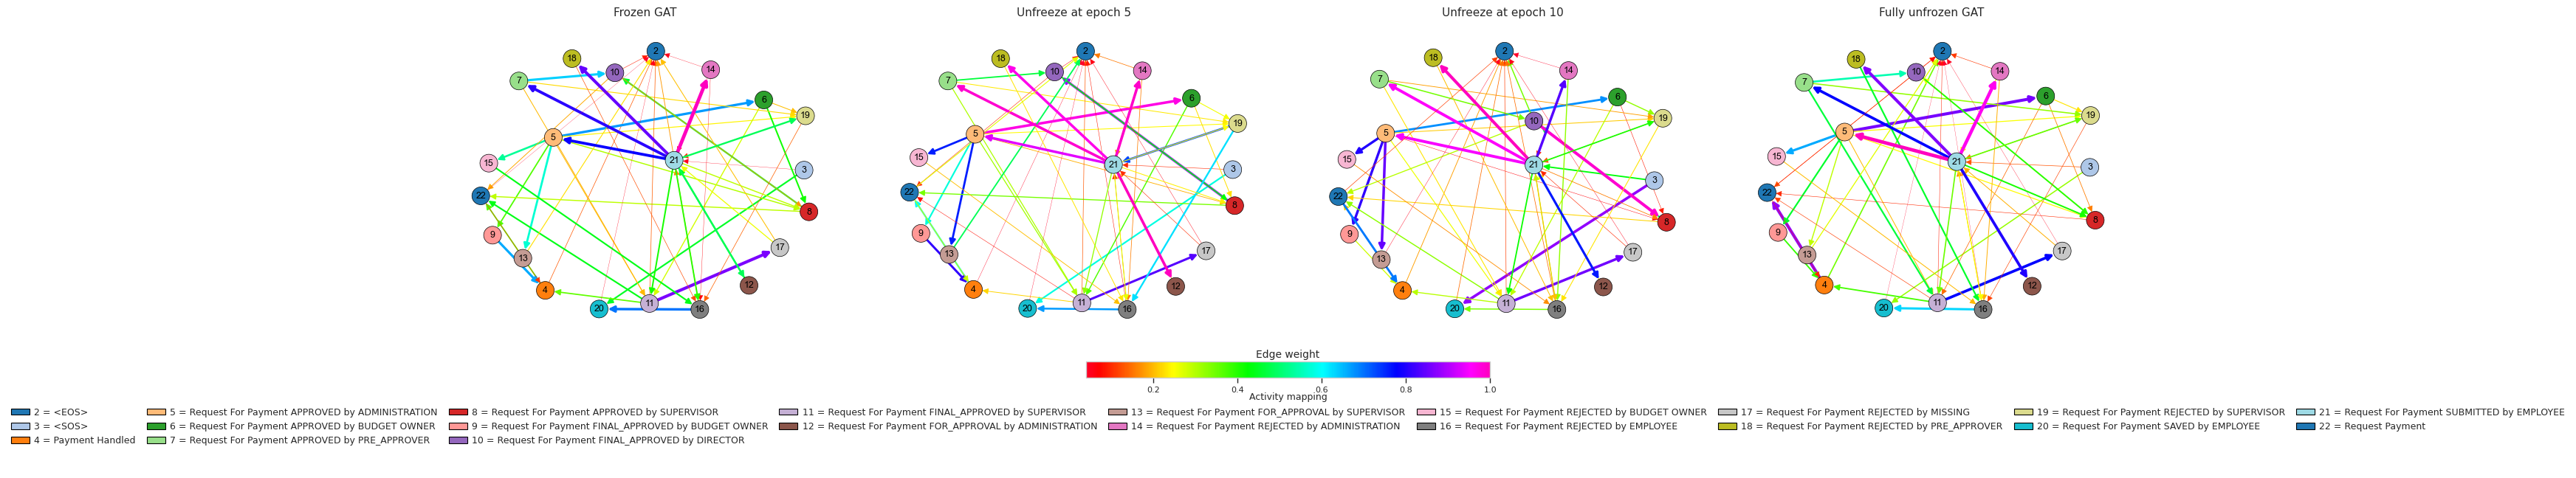

In [30]:
# Prepare the four attention packs
regime_frozen = {
    'attn_pack': attn_frozen,
    'title': 'Frozen GAT'
}
regime_unfreeze_5 = {
    'attn_pack': attn_frozen5,
    'title': 'Unfreeze at epoch 5'
}
regime_unfreeze_10 = {
    'attn_pack': attn_frozen10,
    'title': 'Unfreeze at epoch 10'
}
regime_full = {
    'attn_pack': attn_unfrozen,
    'title': 'Fully unfrozen GAT'
}

plot_gat_attention_panel(
    [regime_frozen, regime_unfreeze_5, regime_unfreeze_10, regime_full],
    remove_nodes=[0, 1],  # pad, unk
    figsize=(24, 4),
    save_path="../output/plots/" + dataname + "_gat_attention_panel",
    dpi=300,
    edge_cmap='gist_rainbow',
    node_palette='tab20',
    node_size=300,
    edge_thresh=0.01,
    layout_seed=42,
    layout_k=1.5,
    main_title = None,
    legend_ncol=9
)

In [75]:
# pick a small batch from val_loader
#batch = next(iter(val_loader))
#batch = move_batch_to_device(batch, device)

In [93]:
seq_head_hd, case_ids_hd, start_times_hd, lengths_hd = build_holdout_head(hold, case_index, time_col, L_max)

hold_dataset = HoldoutGenerationDataset(seq_head_hd, lengths_hd, case_ids_hd, start_times_hd)

hold_loader = DataLoader(
    hold_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=bpm_collate_fn_hold,
    drop_last=False
)

In [94]:
bigram_prior = build_bigram_prior(
    train_df,
    case_index,
    core_event,
    time_col,
    act2id=vocabs["activity"],
    n_act=len(vocabs["activity"]),
    include_eos= True
)

In [95]:
checkpoint_joint_stage10 = load_for_inference(model_joint_stage10, gat_encoder, model_path_joint_stage10, device)
#checkpoint = load_for_training(model, gat_encoder, optimizer, scheduler, model_path, device)

print("Loaded best checkpoint from epoch:", checkpoint_joint_stage10.get("epoch"), "Best score:", checkpoint_joint_stage10.get("best_score"), "Best NO EOS Act Acc:", checkpoint_joint_stage10.get("best_act_acc"))


Loaded best checkpoint from epoch: 51 Best score: 0.5165343190411844 Best NO EOS Act Acc: 0.5110446214675903


In [96]:

if dataname == "BPI13I" or dataname == "BPI17":
    temperature = 1
    greedy = True
    top_k = None
    time_sigma = 0.0
    adj_m = True
    bigram_prior = None
else:
    temperature = 1.5
    greedy = False
    top_k = None
    time_sigma  = 0.02
    adj_m = True
if dataname == "BPI20" or dataname == "sepsis" :
    bigram_prior = None

all_rows = []
for batch in hold_loader:
    batch = move_batch_to_device(batch, device)
    df_batch, gen_batch = generate_full_log(model_joint_stage10, gat_encoder, head_graph_tr, batch, device, vocabs, num_stats, time_stats, temperature, greedy, top_k, time_sigma, bigram_prior, time_min_scaled,
        time_max_scaled, adj_m)
    all_rows.append(df_batch)

df_gen = pd.concat(all_rows, ignore_index=True)


gen real lengths: [22, 8, 17, 13, 25, 14, 19, 12, 14, 16]
gen total lengths: [23, 9, 18, 14, 26, 15, 20, 13, 15, 17]
target real lens: [22, 8, 17, 13, 25, 14, 19, 12, 14, 16]


In [97]:
df_gen = df_gen.rename(columns={'case_id': 'case:concept:name', 'activity': 'concept:name', 'time_timestamp': 'time:timestamp'})
df_gen.to_csv("../output/gen_traces/" + dataname + "_gen_gat_joint_stage10.csv", index=False)

In [98]:
eval_light = evaluate_light(df_gen, hold, case_index, core_event, time_col, "pos", name="GGATN_s10", jsd_lambda=1.0)

bol_cols_event = []
bol_cols_seq = []

eval_comp =evaluate_comprehensive(df_gen, hold, case_index, core_event, time_col, "pos", 
                       [core_event] + cat_cols_event, num_cols_event, bol_cols_event,
                       cat_cols_seq, num_cols_seq, bol_cols_seq,
                       name="GGATN_s10", jsd_lambda=1.0
                      )
# Add metadata columns
eval_comp["length_bucket"] = "all"
eval_comp['data'] = dataname
eval_comp["num_cases"] = df_gen[case_index].nunique()
eval_comp = eval_comp.reset_index().rename(columns={'index': 'model'})

#eval_comp.to_csv("../output/metrics/" + dataname + "_joint_stage10_eval.csv", index=False)

In [99]:
eval_comp

,model,seq_coverage,bigram_jsd_unconditional,trace_similarity_unconditional,duration_wd_unconditional,dl_similarity_unconditional,bigram_jsd_conditional,trace_similarity_conditional,duration_wd_conditional,dl_similarity_conditional,hallucinated_activities,activity_recall,event_concept:name_accuracy_unconditional,event_org:group_accuracy_unconditional,event_concept:name_accuracy_conditional,event_org:group_accuracy_conditional,event_Leucocytes_mae_unconditional,event_CRP_mae_unconditional,event_LacticAcid_mae_unconditional,event_Leucocytes_mae_conditional,event_CRP_mae_conditional,event_LacticAcid_mae_conditional,seq_InfectionSuspected_accuracy_unconditional,seq_DiagnosticBlood_accuracy_unconditional,seq_DisfuncOrg_accuracy_unconditional,seq_SIRSCritTachypnea_accuracy_unconditional,seq_Hypotensie_accuracy_unconditional,seq_SIRSCritHeartRate_accuracy_unconditional,seq_Infusion_accuracy_unconditional,seq_DiagnosticArtAstrup_accuracy_unconditional,seq_DiagnosticIC_accuracy_unconditional,seq_DiagnosticSputum_accuracy_unconditional,seq_DiagnosticLiquor_accuracy_unconditional,seq_DiagnosticOther_accuracy_unconditional,seq_SIRSCriteria2OrMore_accuracy_unconditional,seq_DiagnosticXthorax_accuracy_unconditional,seq_SIRSCritTemperature_accuracy_unconditional,seq_DiagnosticUrinaryCulture_accuracy_unconditional,seq_SIRSCritLeucos_accuracy_unconditional,seq_Oligurie_accuracy_unconditional,seq_DiagnosticLacticAcid_accuracy_unconditional,seq_Diagnose_accuracy_unconditional,seq_Hypoxie_accuracy_unconditional,seq_DiagnosticUrinarySediment_accuracy_unconditional,seq_DiagnosticECG_accuracy_unconditional,seq_InfectionSuspected_accuracy_conditional,seq_DiagnosticBlood_accuracy_conditional,seq_DisfuncOrg_accuracy_conditional,seq_SIRSCritTachypnea_accuracy_conditional,seq_Hypotensie_accuracy_conditional,seq_SIRSCritHeartRate_accuracy_conditional,seq_Infusion_accuracy_conditional,seq_DiagnosticArtAstrup_accuracy_conditional,seq_DiagnosticIC_accuracy_conditional,seq_DiagnosticSputum_accuracy_conditional,seq_DiagnosticLiquor_accuracy_conditional,seq_DiagnosticOther_accuracy_conditional,seq_SIRSCriteria2OrMore_accuracy_conditional,seq_DiagnosticXthorax_accuracy_conditional,seq_SIRSCritTemperature_accuracy_conditional,seq_DiagnosticUrinaryCulture_accuracy_conditional,seq_SIRSCritLeucos_accuracy_conditional,seq_Oligurie_accuracy_conditional,seq_DiagnosticLacticAcid_accuracy_conditional,seq_Diagnose_accuracy_conditional,seq_Hypoxie_accuracy_conditional,seq_DiagnosticUrinarySediment_accuracy_conditional,seq_DiagnosticECG_accuracy_conditional,seq_Age_mae_unconditional,seq_Age_mae_conditional,timestamp_mae_unconditional,timestamp_mae_conditional,seq_InfectionSuspected_inconsistent_cases,seq_InfectionSuspected_inconsistent_pct,seq_DiagnosticBlood_inconsistent_cases,seq_DiagnosticBlood_inconsistent_pct,seq_DisfuncOrg_inconsistent_cases,seq_DisfuncOrg_inconsistent_pct,seq_SIRSCritTachypnea_inconsistent_cases,seq_SIRSCritTachypnea_inconsistent_pct,seq_Hypotensie_inconsistent_cases,seq_Hypotensie_inconsistent_pct,seq_SIRSCritHeartRate_inconsistent_cases,seq_SIRSCritHeartRate_inconsistent_pct,seq_Infusion_inconsistent_cases,seq_Infusion_inconsistent_pct,seq_DiagnosticArtAstrup_inconsistent_cases,seq_DiagnosticArtAstrup_inconsistent_pct,seq_DiagnosticIC_inconsistent_cases,seq_DiagnosticIC_inconsistent_pct,seq_DiagnosticSputum_inconsistent_cases,seq_DiagnosticSputum_inconsistent_pct,seq_DiagnosticLiquor_inconsistent_cases,seq_DiagnosticLiquor_inconsistent_pct,seq_DiagnosticOther_inconsistent_cases,seq_DiagnosticOther_inconsistent_pct,seq_SIRSCriteria2OrMore_inconsistent_cases,seq_SIRSCriteria2OrMore_inconsistent_pct,seq_DiagnosticXthorax_inconsistent_cases,seq_DiagnosticXthorax_inconsistent_pct,seq_SIRSCritTemperature_inconsistent_cases,seq_SIRSCritTemperature_inconsistent_pct,seq_DiagnosticUrinaryCulture_inconsistent_cases,seq_DiagnosticUrinaryCulture_inconsistent_pct,seq_SIRSCritLeucos_inconsistent_cases,seq_SIRSCritLeucos_inconsistent_pct,seq_Oligurie_inconsistent_

In [100]:
#all_eval = pd.read_csv("../output/metrics/" + dataname + "_eval.csv")
# Find the index of the matching row in all_eval
#matching_index = all_eval[all_eval['model'] == "GGATN_s10"].index
#all_eval.loc[matching_index[0], eval_comp.columns] = eval_comp.iloc[0].values

In [101]:
all_eval = pd.read_csv("../output/metrics/" + dataname+ "_eval.csv")
all_eval = pd.concat([all_eval, eval_comp], ignore_index=True)
all_eval.to_csv("../output/metrics/" + dataname + "_eval.csv", index = False)